In [28]:
import networkx as nx
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv
import scipy.io as sio
from torch_geometric.utils import from_scipy_sparse_matrix


In [23]:
pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 MB 10.2 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [24]:
pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.2.0+cpu.html


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.8/511.8 kB 10.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.6/776.6 kB 43.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.8/215.8 kB 11.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install -q torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


# Exercise 1

## 1

In [11]:

path_txt = "/kaggle/input/labad6/ca-AstroPh.txt"

graph = nx.Graph()

with open(path_txt, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        node1, node2 = map(int, line.split())
        if graph.has_edge(node1, node2):
            graph[node1][node2]['weight'] += 1
        else:
            graph.add_edge(node1, node2, weight=1)

print(graph.number_of_nodes())
print(graph.number_of_edges())


18772
198110


## 2

In [12]:
node_num_neighbors = {}
node_num_egonet_edges = {}
node_total_egonet_weight = {}
node_principal_eigenvalue = {}

for node in graph.nodes():

    neighbor_list = list(graph.neighbors(node))
    node_num_neighbors[node] = len(neighbor_list)

    egonet_subgraph = graph.subgraph(neighbor_list)
    node_num_egonet_edges[node] = egonet_subgraph.number_of_edges()

    weight_sum = 0
    for node1, node2, data in egonet_subgraph.edges(data=True):
        weight_sum += data.get("weight", 1)
    node_total_egonet_weight[node] = weight_sum

    if egonet_subgraph.number_of_nodes() > 0:
        nodes_in_egonet = list(egonet_subgraph.nodes())
        index_map = {n: i for i, n in enumerate(nodes_in_egonet)}
        adjacency_matrix = np.zeros((len(nodes_in_egonet), len(nodes_in_egonet)))

        for node1, node2, data in egonet_subgraph.edges(data=True):
            w = data.get("weight", 1)
            adjacency_matrix[index_map[node1], index_map[node2]] = w
            adjacency_matrix[index_map[node2], index_map[node1]] = w

        eigenvalues = np.linalg.eigvals(adjacency_matrix)
        node_principal_eigenvalue[node] = float(max(eigenvalues.real))
    else:
        node_principal_eigenvalue[node] = 0.0

nx.set_node_attributes(graph, node_num_neighbors, "Ni")
nx.set_node_attributes(graph, node_num_egonet_edges, "Ei")
nx.set_node_attributes(graph, node_total_egonet_weight, "Wi")
nx.set_node_attributes(graph, node_principal_eigenvalue, "Lambda")


## 3

In [17]:
Ni_values = []
Ei_values = []
node_list = []

for node in graph.nodes():
    x = graph.nodes[node]["Ni"]
    y = graph.nodes[node]["Ei"]
    if x > 0 and y > 0:
        Ni_values.append(x)
        Ei_values.append(y)
        node_list.append(node)

Ni_log = np.log(np.array(Ni_values)).reshape(-1, 1)
Ei_log = np.log(np.array(Ei_values))

model = LinearRegression()
model.fit(Ni_log, Ei_log)

theta = model.coef_[0]
C = np.exp(model.intercept_)

anomaly_scores = {}

for i, node in enumerate(node_list):
    x = Ni_values[i]
    y = Ei_values[i]
    predicted = C * (x ** theta)

    ratio = max(y, predicted) / min(y, predicted)
    deviation = np.log(abs(y - predicted) + 1)

    anomaly_scores[node] = ratio * deviation

nx.set_node_attributes(graph, anomaly_scores, "OddBallScore")

## 4

In [ ]:
sorted_nodes = sorted(
    graph.nodes(),
    key=lambda n: graph.nodes[n]["OddBallScore"] if "OddBallScore" in graph.nodes[n] else 0,
    reverse=True
)

top10_nodes = set(sorted_nodes[:10])

node_colors = []
for node in graph.nodes():
    if node in top10_nodes:
        node_colors.append("red")
    else:
        node_colors.append("skyblue")

plt.figure(figsize=(12, 10))
nx.draw(
    graph,
    node_color=node_colors,
    node_size=50,
    edge_color="gray",
    with_labels=False
)
plt.title("top 10 oddball anomalies")
plt.show()


## 5

In [ ]:
Ni_list = []
Ei_list = []
nodes_list = []

for node in graph.nodes():
    Ni_list.append(graph.nodes[node]["Ni"])
    Ei_list.append(graph.nodes[node]["Ei"])
    nodes_list.append(node)

NiEi_pairs = np.column_stack((Ni_list, Ei_list))

lof_model = LocalOutlierFactor(n_neighbors=20)
lof_scores = -lof_model.fit_predict(NiEi_pairs)
lof_values = -lof_model.negative_outlier_factor_

odd_scores = np.array([graph.nodes[n]["OddBallScore"] for n in nodes_list])
scaler = MinMaxScaler()
odd_scores_normalized = scaler.fit_transform(odd_scores.reshape(-1, 1)).flatten()

final_anomaly_scores = odd_scores_normalized + lof_values

final_scores_dict = {nodes_list[i]: final_anomaly_scores[i] for i in range(len(nodes_list))}
nx.set_node_attributes(graph, final_scores_dict, "FinalAnomalyScore")

sorted_nodes_final = sorted(
    graph.nodes(),
    key=lambda n: graph.nodes[n]["FinalAnomalyScore"],
    reverse=True
)

top10_final = set(sorted_nodes_final[:10])

node_colors = []
for node in graph.nodes():
    if node in top10_final:
        node_colors.append("orange")
    else:
        node_colors.append("lightblue")

plt.figure(figsize=(12, 10))
nx.draw(
    graph,
    node_color=node_colors,
    node_size=50,
    edge_color="gray",
    with_labels=False
)
plt.title("top 10 anomalies")
plt.show()


# Exercise 2

## 1

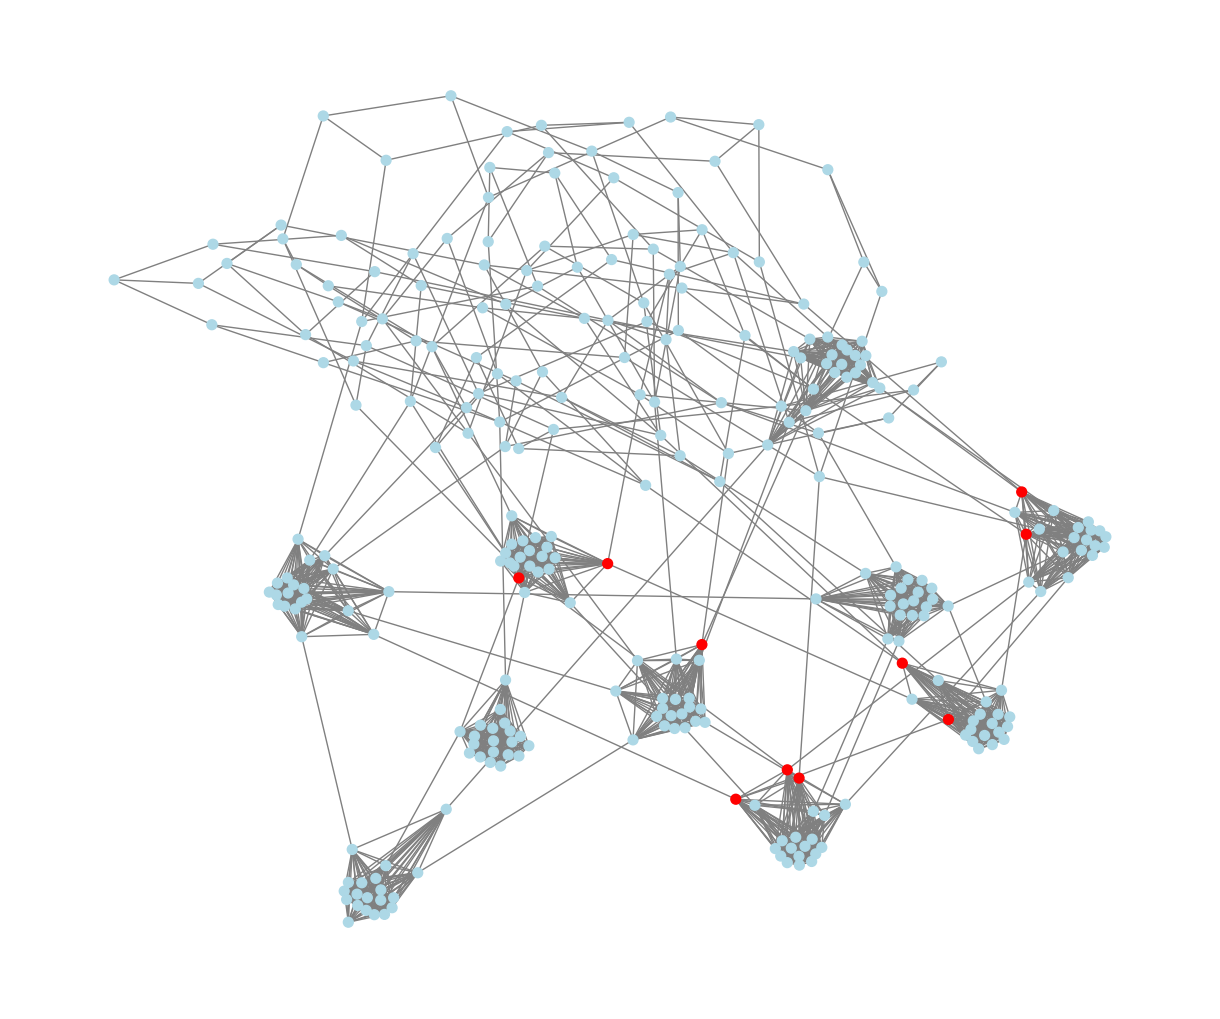

In [34]:
regular_graph = nx.random_regular_graph(d=3, n=100)
caveman_graph = nx.connected_caveman_graph(10, 20)

merged_graph = nx.disjoint_union(regular_graph, caveman_graph)

all_nodes = list(merged_graph.nodes())
for i in range(50):
    n1 = np.random.choice(all_nodes)
    n2 = np.random.choice(all_nodes)
    if n1 != n2:
        merged_graph.add_edge(n1, n2)

Ni_data = []
Ei_data = []
node_list = []

for node in merged_graph.nodes():
    neighbors = list(merged_graph.neighbors(node))
    Ni_data.append(len(neighbors))
    node_list.append(node)

    egonet = merged_graph.subgraph(neighbors)
    Ei_data.append(egonet.number_of_edges())

Ni_arr = np.array(Ni_data)
Ei_arr = np.array(Ei_data)

valid_idx = np.where((Ni_arr > 0) & (Ei_arr > 0))[0]
Ni_log = np.log(Ni_arr[valid_idx]).reshape(-1, 1)
Ei_log = np.log(Ei_arr[valid_idx])

reg = LinearRegression()
reg.fit(Ni_log, Ei_log)

theta = reg.coef_[0]
C = np.exp(reg.intercept_)

scores = {}

for idx, node in enumerate(node_list):
    x = Ni_arr[idx]
    y = Ei_arr[idx]
    if x > 0:
        predicted = C * (x ** theta)
        ratio = max(y, predicted) / min(y, predicted) if min(y, predicted) > 0 else 1
        deviation = np.log(abs(y - predicted) + 1)
        scores[node] = ratio * deviation
    else:
        scores[node] = 0.0

sorted_nodes = sorted(scores.keys(), key=lambda n: scores[n], reverse=True)
top10 = set(sorted_nodes[:10])

node_colors = []
for node in merged_graph.nodes():
    if node in top10:
        node_colors.append("red")
    else:
        node_colors.append("lightblue")

plt.figure(figsize=(12, 10))
nx.draw(
    merged_graph,
    node_color=node_colors,
    node_size=50,
    edge_color="gray",
    with_labels=False
)
plt.title("")
plt.show()


## 2

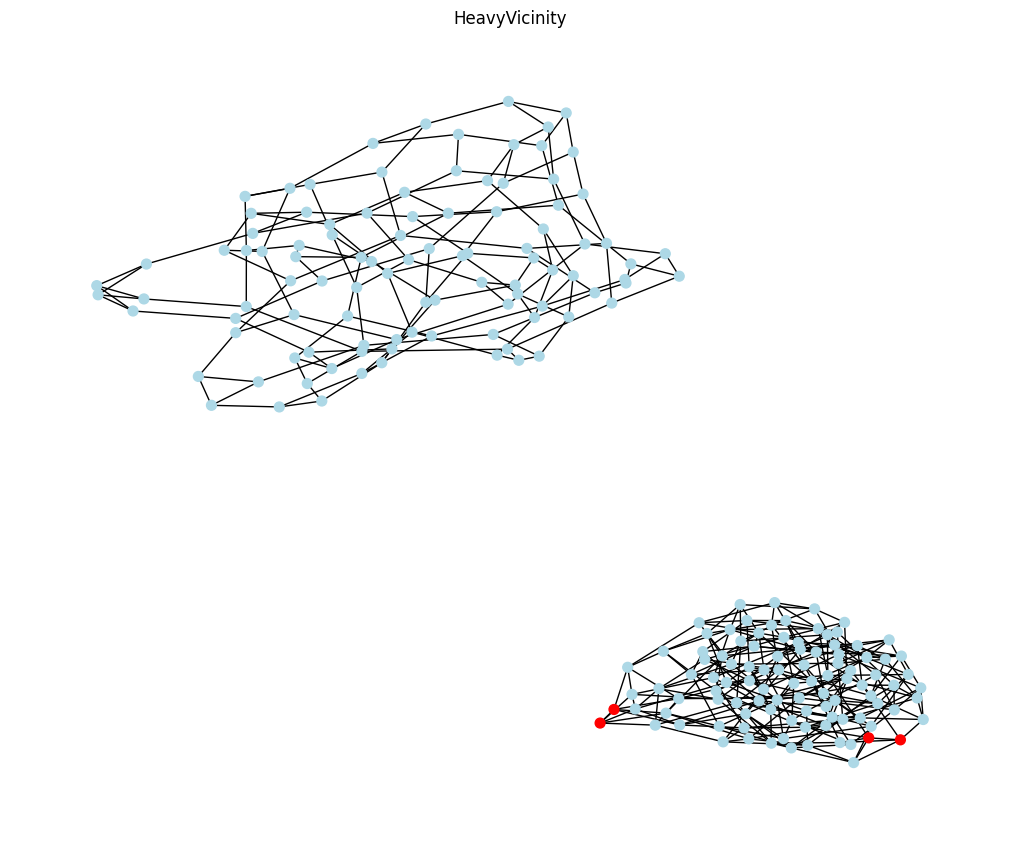

In [36]:
g1 = nx.random_regular_graph(3, 100)
g2 = nx.random_regular_graph(5, 100)

G = nx.disjoint_union(g1, g2)


for a, b in list(G.edges()):
    G.add_edge(a, b, weight=1)

nodes = list(G.nodes())
pick1 = np.random.choice(nodes)
pick2 = np.random.choice(nodes)

for n in G.neighbors(pick1):
    G[pick1][n]["weight"] += 10

for n in G.neighbors(pick2):
    G[pick2][n]["weight"] += 10

Wi = []
Ei = []
node_list = []

for n in G.nodes():
    neigh = list(G.neighbors(n))
    ego = G.subgraph(neigh)

    wsum = sum(d["weight"] for _, _, d in ego.edges(data=True))
    Wi.append(wsum)
    Ei.append(ego.number_of_edges())
    node_list.append(n)

Wi_arr = np.array(Wi)
Ei_arr = np.array(Ei)

valid = np.where((Wi_arr > 0) & (Ei_arr > 0))[0]
x = np.log(Wi_arr[valid]).reshape(-1, 1)
y = np.log(Ei_arr[valid])

lr = LinearRegression()
lr.fit(x, y)

theta = lr.coef_[0]
C = np.exp(lr.intercept_)

scores = {}
for i, n in enumerate(node_list):
    w = Wi_arr[i]
    e = Ei_arr[i]
    if w > 0:
        pred = C * (w ** theta)
        scores[n] = np.log(abs(e - pred) + 1)
    else:
        scores[n] = 0

top4 = sorted(scores, key=scores.get, reverse=True)[:4]
top4 = set(top4)

colors = ["red" if n in top4 else "lightblue" for n in G.nodes()]

plt.figure(figsize=(10, 8))
nx.draw(G, node_color=colors, node_size=50, with_labels=False)
plt.title("HeavyVicinity")
plt.show()


# Exercise 3

In [32]:
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, latent_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, latent_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        z = self.conv2(x, edge_index)
        return z

class AttributeDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, out_dim):
        super().__init__()
        self.lin1 = nn.Linear(latent_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, z):
        h = torch.relu(self.lin1(z))
        x_hat = self.lin2(h)
        return x_hat

class AdjacencyDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

    def forward(self, z):
        logits = torch.matmul(z, z.t())
        A_hat = torch.sigmoid(logits)
        return A_hat

class GraphAutoencoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = GCNEncoder(in_dim, hidden_dim, latent_dim)
        self.attr_decoder = AttributeDecoder(latent_dim, hidden_dim, in_dim)
        self.adj_decoder = AdjacencyDecoder(latent_dim)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        x_hat = self.attr_decoder(z)
        A_hat = self.adj_decoder(z)
        return x_hat, A_hat, z


## 2

In [33]:
path = "/kaggle/input/labad6/ACM.mat"

data = sio.loadmat(path)

X = data["Attributes"]              
A = data["Network"]                 
labels = data["Label"].flatten()    

X = torch.tensor(X.todense(), dtype=torch.float)

edge_index, edge_weight = from_scipy_sparse_matrix(A)

labels = torch.tensor(labels, dtype=torch.long)


## 3

In [37]:

class Encoder(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, 128)
        self.conv2 = GCNConv(128, 64)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        z = torch.relu(x)
        return z


class AttributeDecoder(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lin1 = nn.Linear(64, 128)
        self.lin2 = nn.Linear(128, in_dim)

    def forward(self, z):
        h = torch.relu(self.lin1(z))
        out = self.lin2(h)
        return out  


class StructureDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = GCNConv(64, 64)

    def forward(self, z, edge_index):
        h = self.conv(z, edge_index)
        h = torch.relu(h)
        A_hat = torch.sigmoid(h @ h.t()) 
        return A_hat


class GraphAutoencoder(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.encoder = Encoder(in_dim)
        self.attr_decoder = AttributeDecoder(in_dim)
        self.struct_decoder = StructureDecoder()

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        x_hat = self.attr_decoder(z)
        A_hat = self.struct_decoder(z, edge_index)
        return x_hat, A_hat, z


## 4

In [43]:
def graph_ae_loss(X, X_hat, A, A_hat, alpha=0.8):
    attr_loss = torch.sum((X - X_hat) ** 2)
    struct_loss = torch.sum((A - A_hat) ** 2)
    total_loss = alpha * attr_loss + (1 - alpha) * struct_loss
    return total_loss, attr_loss, struct_loss

gae = GraphAutoencoder(in_dim=X.shape[1])
A_dense = torch.tensor(A.todense(), dtype=torch.float32)
x_hat, A_hat, z = gae(X, edge_index)
loss, attr_loss, struct_loss = graph_ae_loss(X, x_hat, A_dense, A_hat)
